<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day19_practice1_%ED%8C%A8%EC%B9%98_%EC%9E%84%EB%B2%A0%EB%94%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 패치 임베딩 - 이미지를 '단어들'로 만든다

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, os, urllib.request
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# 셀 1. 데이터 - F-MNIST
def load_fmnist(root="./data", train=True):
  tf = transforms.ToTensor() # 이미지(0-255) → 텐서(0-1)
  return datasets.FashionMNIST(root=root, train=train, download=True, transform=tf)

data = load_fmnist()
img, label = data[0] # img:(1,28,28)
print("이미지:", tuple(img.shape), "| 클래스:", data.classes[label])

100%|██████████| 26.4M/26.4M [00:01<00:00, 22.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 339kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.5MB/s]

이미지: (1, 28, 28) | 클래스: Ankle boot


패치화: (1,1,28,28) → (1, 16, 49)


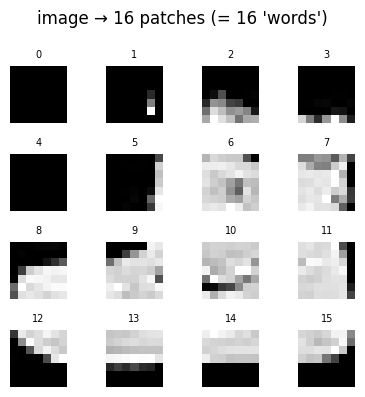

In [6]:
# 셀 2. 패치 자르기 - 28×28을 7×7짜리 16조각으로
PATCH = 7 # 패치 한 번 (7픽셀)
N_SIDE = 28 // PATCH # 한 줄에 4개 → 총 4×4=16개

def to_patches(images):
  B = images.shape[0]
  p = images.unfold(2, PATCH, PATCH).unfold(3,PATCH, PATCH) # (B, 1, 4, 4, 7, 7) 4×4개, 7×7패치
  # unfold(2, PATCH, PATCH) 2번째축을 PATCH 크기로 PATCH 간격으로 슬라이딩해 조각냄, 세로 28을 7씩 4조각
  # unfold(3, PATCH, PATCH) 가로 28을 7씩 4조각
  return p.reshape(B, N_SIDE * N_SIDE, PATCH * PATCH) # (B,16,49) : 패치 16개 × 49차원

patches = to_patches(img.unsqueeze(0)) # img:(1,28,28) → (1,1,28,28) → (B,16,49)
print(f"패치화: (1,1,28,28) → {tuple(patches.shape)}") # 이미지1장→한 문장, 패치 16개 → 단어 16개, 49픽셀 → 49차원 벡터

fig, axes = plt.subplots(N_SIDE, N_SIDE, figsize=(4,4))
for i, ax in enumerate(axes.flat):
  ax.imshow(patches[0,i].reshape(PATCH, PATCH), cmap="gray") # patches[0,i]:(49,) → reshape:(7,7)
  ax.set_title(str(i), fontsize=7); ax.axis("off")
plt.suptitle("image → 16 patches (= 16 'words')")
plt.tight_layout(); plt.savefig("plot1_patches.png")
plt.show()

In [8]:
# 셀 3. 패치 임베딩 - Linear 하나면 '단어 벡터'가 된다
DIM = 64
patch_embed = nn.Linear(PATCH * PATCH, DIM) # (49→64)
tokens = patch_embed(patches) # (1,16,49) → (1,16,64) 각 패치 49픽셀 → 64차원 토큰
print(f"패치 임베딩: {tuple(patches.shape)} → {tuple(tokens.shape)}")

# 언어 : 단어 번호 → nn.Embedding(표에서 꺼냄) → (B, 문장 길이, 64)
# ViT : 패치 픽셀 → nn.Linear(곱해서 변환) → (B, 패치수, 64)

패치 임베딩: (1, 16, 49) → (1, 16, 64)


In [15]:
# 셀 4. [CLS]
# [CLS] 토큰: "문장 요약 담당" 특수 토큰을 맨 앞에 하나 추가, 어텐션을 거치며 모든 매치의 정보를 모아 오고
# 분류는 이 [CLS] 다리의 최종 벡터 하나로 한다
cls_token = nn.Parameter(torch.zeros(1,1,DIM)) # (1B,1토큰, 64차원 벡터) 학습되는 벡터 1개
x = torch.cat([cls_token.expand(1,-1,-1), tokens], dim=1) # (1,1,64) + (1,16,64) → (1,17,64) dim=1(토큰 축)으로 이어붙이니 토큰 개수 17
print(x[0,0],"\n") # (1,17,64) CLS
print(x[0,16]) # 마지막 패치
print(f"\n[CLS] 추가: (1,16,64) → {tuple(x.shape)} ← 17토큰")

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       grad_fn=<SelectBackward0>) 

tensor([ 0.6432, -0.4166, -0.2053,  0.2534, -0.1830,  0.1087, -0.3399, -0.3645,
         0.1244,  0.0848, -0.3899, -0.5510, -0.3262,  0.1512, -0.4932,  0.1996,
        -0.1624,  0.2285, -0.0543, -0.2100,  0.1674,  0.1981,  0.1430, -0.0539,
        -0.2546, -0.4985, -0.5213,  0.3212, -0.0851,  0.3067,  0.3085,  0.2551,
        -0.0997,  0.1172, -0.2002, -0.3392, -0.1293,  0.4047,  0.1430,  0.0940,
         0.1639, -0.0009, -0.5462,  0.0263,  0.2059, -0.3883, -0.0700,  0.1614,
         0.2296,  0.3176,  0.1910,  0.2684,  0.1848,  0.4071, -0.1611,  0.2473,
        -0.3799, -0.7998,  0.4299, -0.0889, -0.0091, -0.5644, -0.3191,  0.0602],
       grad_fn=<SelectBackward0>)

[CLS] 추

In [21]:
# 셀 5. 위치 임베딩
pos_embed = nn.Parameter(torch.zeros(1,17,DIM)) # 17자리 각각의 위치 벡터
x = x + pos_embed
print(x.shape,"\n", x)

torch.Size([1, 17, 64]) 
 tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0562,  0.0051,  0.1074,  ..., -0.0540,  0.0112,  0.1074],
         [ 0.0543,  0.0062,  0.1043,  ..., -0.0530,  0.0116,  0.1072],
         ...,
         [ 0.5611, -0.6243, -0.5229,  ..., -0.8106, -0.2708,  0.2233],
         [ 0.6306, -0.5269, -0.4565,  ..., -0.7399, -0.2616,  0.2055],
         [ 0.6432, -0.4166, -0.2053,  ..., -0.5644, -0.3191,  0.0602]]],
       grad_fn=<AddBackward0>)
